# Using a transfer learning model


Using a different model works in principle the same as the model used in the miniML tutorial. There are a few details to keep in mind, which will be highlighted in the following.


In [1]:
from miniml import EventDetection, TraceLoader
from miniml.plotting import Plotter


## Running miniML


Generating the trace object works the same as in the miniML tutorial. Here, we use an mEPSP recording example saved as .h5 file. The trace is loaded using the `TraceLoader` class.


In [11]:
filename = "../../example_data/gc_mEPSP_mini_trace.h5"
scaling = 1e3
unit = "mV"

# load from h5 file
trace = TraceLoader.from_h5_file(
    filename=filename, tracename="mini_data", scaling=scaling, sampling=2e-5, unit=unit
)

Let's plot the loaded data:


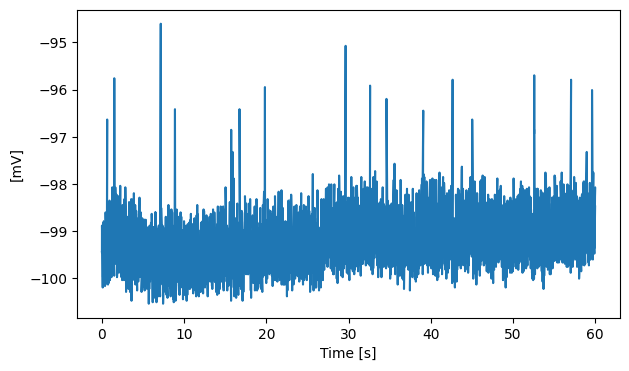

In [12]:
trace.plot_trace()

Creating and initializing a miniML _EventDetection_ object also works very similar. Three things have to be considered here:

- Path to the new model has to be specified:
  Either one of our TL models, or the model you trained for your preparation of interest

- Window size (variable _win_size_) has to be specified:
  Our initial model has a window size of 600 points. This was big enough to fully capture one event in cerebellar granule cells. Depending on event kinetics and sampling rate, 600 points may be too much or too little. For example, for our recordings of mEPSPs in the same cell we need 3000 points (see below). The specified window size will also be used to resample the trace for prediction. It is important to use the same window size that the training data has, to prevent a shift in kinetics, which can negatively impact performance. More on this is specified in the documentation for transfer learning.

- You may need to change the two direction parameters:
  "event_direction" specifies the direction of the events in the data and "training_direction" specifies the direction of the events during training. For transfer learning, we typically invert positive events. This improved model performance and made TL easier. This is for example the case for the mEPSP model we use here. In that case, event_direction has to be changed to 'positive', and training direction has to be set to 'negative' as shown below.


In [8]:
model = "../../models/transfer_learning/GC_mEPSP/lstm_transfer.h5"
win_size = 3000
threshold = 0.5
event_direction = "positive"
training_direction = "negative"

detection = EventDetection(
    data=trace,
    model=model,
    window_size=win_size,
    model_threshold=threshold,
    batch_size=512,
    event_direction=event_direction,
    training_direction=training_direction,
    compile_model=True,
    verbose=2,
)

Model loaded from ../../models/transfer_learning/GC_mEPSP/lstm_transfer.h5


In [9]:
detection.detect_events(eval=True, 
                        convolve_win=30, 
                        gradient_convolve_win=30, 
                        resample_to_600=True,
                        )

59/59 - 2s - 2s/epoch - 40ms/step

Event statistics:
-------------------------
    Number of events: 23
    Average score: 0.929
    Event frequency: 0.3833 Hz
    Mean amplitude: 2.5080 mV
    Median amplitude: 2.8621 mV
    Std amplitude: 1.1049 mV
    CV amplitude: 0.441
    Mean charge: 0.02690 pC
    CV charge: 0.647
    Mean 10-90 risetime: 1.393 ms
    Mean half decay time: 5.722 ms
    Mean half-width: 18.362 ms
    Tau decay: 8.732 ms
-------------------------


## Inspect the results


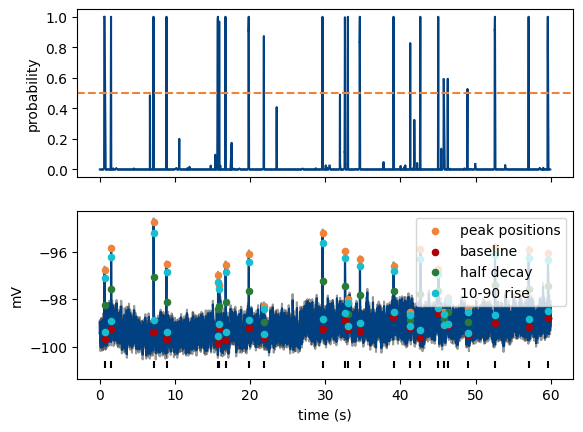

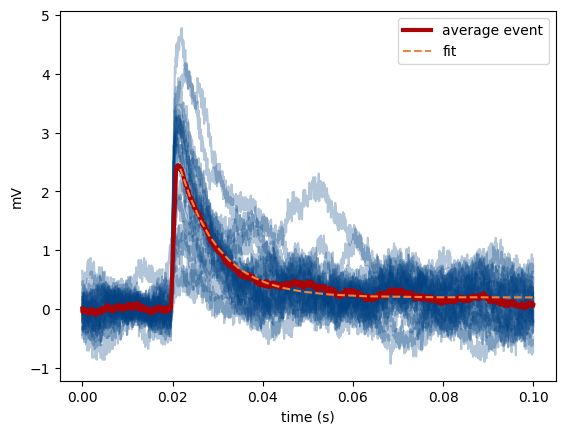

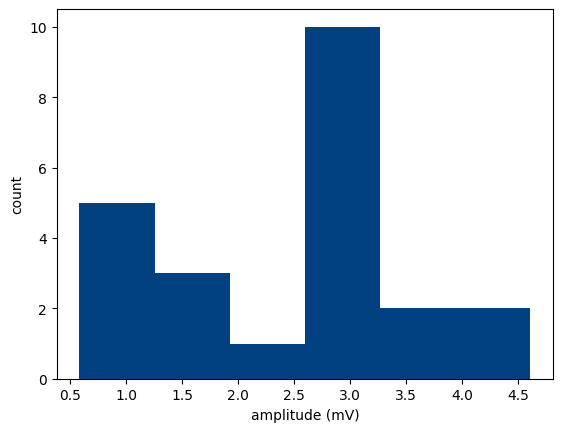

In [10]:
MiniPlots = Plotter(data=detection)

MiniPlots.plot_prediction(
    include_data=True,
    plot_filtered_prediction=True,
    plot_filtered_trace=True,
    plot_event_params=True,
)
MiniPlots.plot_event_overlay()
MiniPlots.plot_event_histogram(plot="amplitude", cumulative=False)

## Save results to file


To save your results, use the same functions shown in the base tutorial.
